In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Technical Content/data/ethiopia.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [4]:
import pandas as pd
import numpy as np

df["Country"] = "Ethiopia"

df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df["Month"] = df["date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [5]:
df.isna().sum()

,0
YEAR,0
DOY,0
T2M,0
T2M_MAX,0
T2M_MIN,0
T2M_RANGE,0
PRECTOTCORR,0
RH2M,0
WS2M,0
WS2M_MAX,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


<Axes: title={'center': 'Average Monthly Temperature in Ethiopia'}, xlabel='Month'>

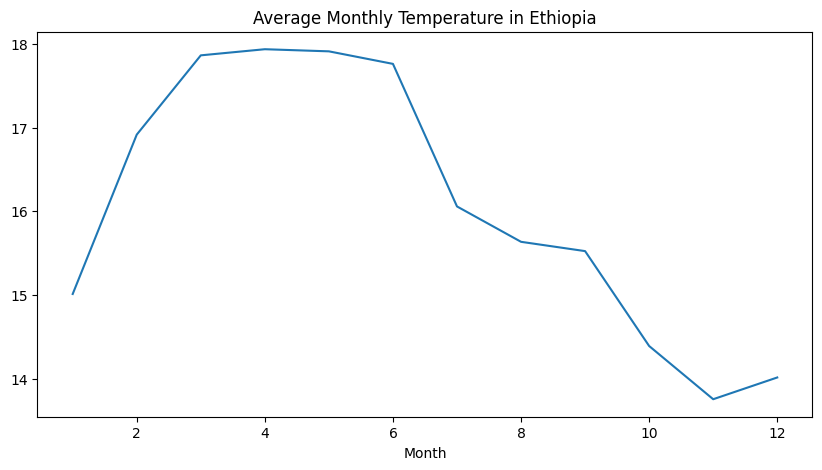

In [8]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(
    figsize=(10,5),
    title="Average Monthly Temperature in Ethiopia"
)

<Axes: title={'center': 'Monthly Total Rainfall in Ethiopia'}, xlabel='Month'>

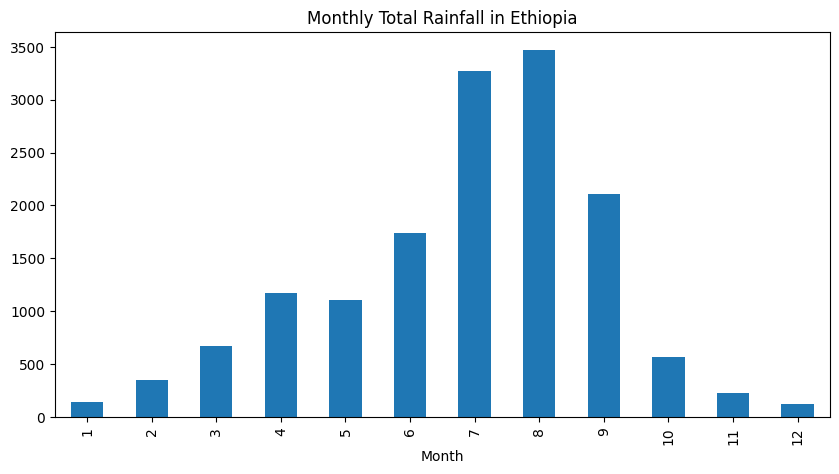

In [9]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(
    kind="bar",
    figsize=(10,5),
    title="Monthly Total Rainfall in Ethiopia"
)

Rainfall is concentrated in the mid-year wet season, with peak precipitation during June to September, corresponding to Ethiopia’s main rainy season. This strong seasonal dependence highlights the importance of rainfall timing for agriculture and water resources.

In [10]:
monthly_temp = df.groupby("Month")["T2M"].mean()
print(monthly_temp)

Month
1     15.012608
2     16.916313
3     17.863333
4     17.936485
5     17.911144
6     17.761364
7     16.058446
8     15.635865
9     15.524818
10    14.391232
11    13.755606
12    14.015308
Name: T2M, dtype: float64


In [12]:
from scipy.stats import zscore
import numpy as np

cols = [
'T2M','T2M_MAX','T2M_MIN',
'PRECTOTCORR','RH2M','WS2M'
]

z = np.abs(zscore(df[cols]))

((z > 3).sum())

np.int64(132)

A total of 132 observations were flagged as potential outliers using Z-scores. These were retained because they likely represent genuine extreme weather conditions such as heavy rainfall events or unusual temperature variability rather than data errors.

<Axes: xlabel='Month'>

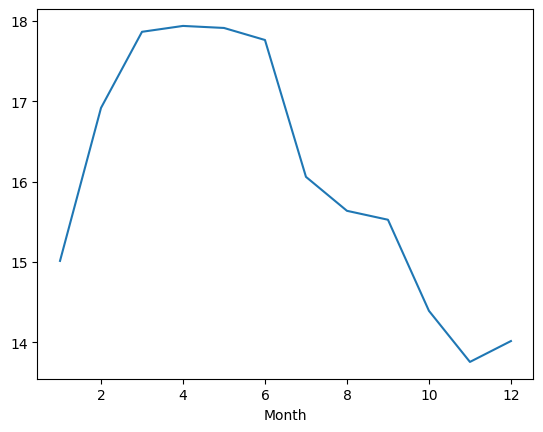

In [13]:
df.groupby('Month')['T2M'].mean().plot()

Average temperature peaks around the 4th month, making it the warmest month, while the 11th month is the coolest month. This reflects a clear seasonal cycle, with relatively mild but observable annual temperature variation.

<Axes: xlabel='YEAR'>

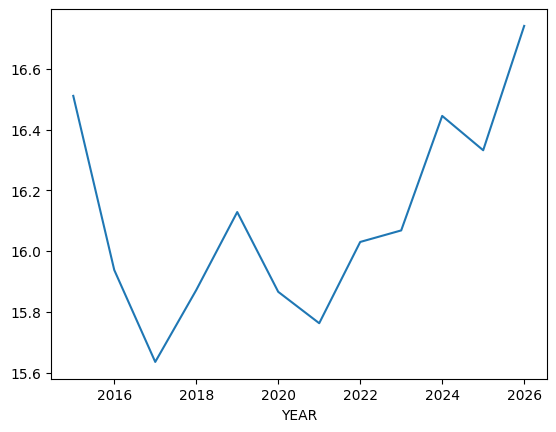

In [14]:
df.groupby('YEAR')['T2M'].mean().plot()

In [16]:
import matplotlib.pyplot as plt


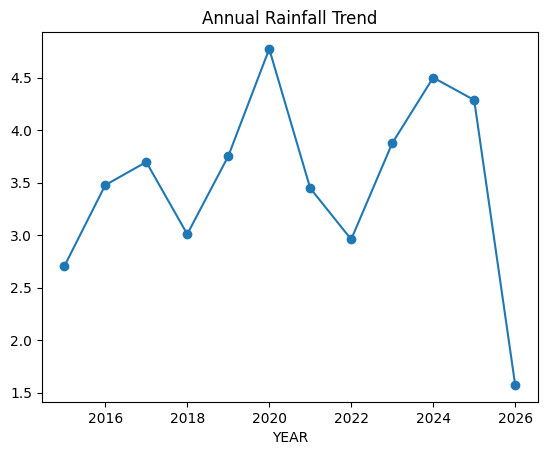

In [17]:
yearly_rain = df.groupby('YEAR')['PRECTOTCORR'].mean()

yearly_rain.plot(marker='o')
plt.title('Annual Rainfall Trend')
plt.show()

In [18]:
(df['T2M_MAX'] > 35).sum()

np.int64(0)

No days exceeded 35°C, indicating low exposure to severe heat extremes. Compared with hotter neighboring countries, Ethiopia appears less vulnerable to direct heat stress.

In [19]:
(df['PRECTOTCORR'] > 20).sum()

np.int64(128)

Ethiopia recorded 128 heavy rainfall days (above 20 mm), suggesting notable exposure to intense precipitation events, which may contribute to flooding and agricultural disruption.

<Axes: >

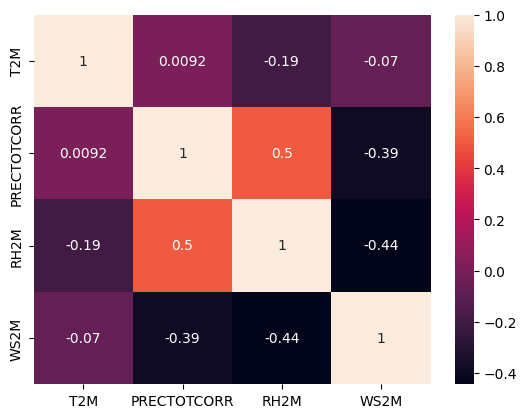

In [20]:
import seaborn as sns

corr = df[['T2M','PRECTOTCORR','RH2M','WS2M']].corr()

sns.heatmap(corr, annot=True)

Strong positive relationships exist among temperature variables, reflecting consistent thermal behavior. Temperature and humidity show a negative association, while precipitation appears weakly correlated with temperature, suggesting rainfall is driven by seasonal dynamics rather than simple temperature effects.

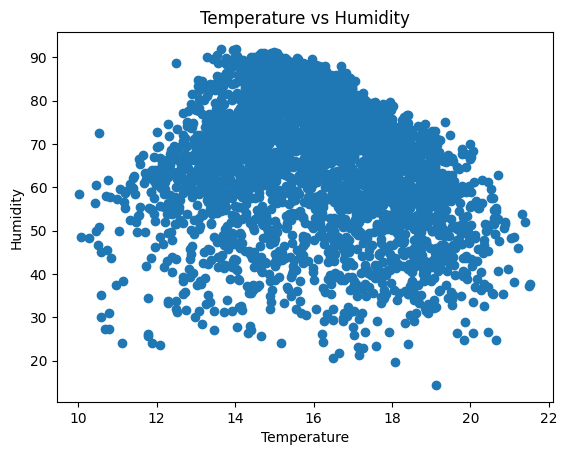

In [21]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature vs Humidity")
plt.show()

The scatter plot suggests an inverse relationship between temperature and humidity, with higher temperatures generally associated with lower relative humidity.

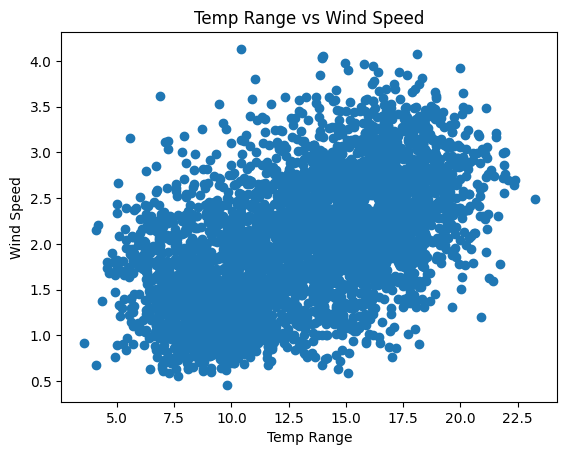

In [22]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temp Range")
plt.ylabel("Wind Speed")
plt.title("Temp Range vs Wind Speed")
plt.show()